# Week 2 Assignment: Market Regime Simulator using Markov Chains
**Equilibrium Gambit — Summer Project**
    -Mansoju Vivekananda(240628)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

# Set seed for reproducibility
np.random.seed(42)
random.seed(42)

# Define states and colors for plotting
STATE_NAMES = {0: "Bull", 1: "Bear", 2: "Sideways"}
STATE_COLORS = {0: "#2ecc71", 1: "#e74c3c", 2: "#f1c40f"}

# Transition matrix: P[i][j] = prob of going from state i to state j
P = np.array([
    [0.7, 0.2, 0.1],
    [0.3, 0.5, 0.2],
    [0.4, 0.3, 0.3],
])

print("Transition Matrix P:")
display(pd.DataFrame(P, index=["Bull","Bear","Sideways"], columns=["Bull","Bear","Sideways"]))


Transition Matrix P:


,Bull,Bear,Sideways
Bull,0.7,0.2,0.1
Bear,0.3,0.5,0.2
Sideways,0.4,0.3,0.3


## Task 1: Market Evolution Simulation
Starting from the Bull state, we simulate the market for 500 days.


In [2]:
NUM_DAYS = 500
INITIAL_STATE = 0  # Bull

def simulate_markov_chain(trans_mat, init_state, n_steps):
    n_states = trans_mat.shape[0]
    states = [init_state]
    cur = init_state
    for _ in range(n_steps):
        cur = np.random.choice(n_states, p=trans_mat[cur])
        states.append(cur)
    return states

states = simulate_markov_chain(P, INITIAL_STATE, NUM_DAYS)
print(f"Simulated {NUM_DAYS} days starting from {STATE_NAMES[INITIAL_STATE]}")
print(f"First 20 states: {[STATE_NAMES[s] for s in states[:20]]}")


Simulated 500 days starting from Bull
First 20 states: ['Bull', 'Bull', 'Sideways', 'Sideways', 'Bear', 'Bull', 'Bull', 'Bull', 'Bear', 'Bear', 'Bear', 'Bull', 'Sideways', 'Sideways', 'Bull', 'Bull', 'Bull', 'Bull', 'Bull', 'Bull']


## Task 1, Part 2: Frequency Analysis
In this section, we count how many times each market state occurred during our 500-day simulation and calculate their empirical fractions.

**How do we find the Theoretical Steady-State?**
To compare our simulation against theoretical expectations, we need to find the **stationary distribution (steady-state)** of our Markov Chain. The steady-state distribution, denoted as $\pi$, satisfies the equation $\pi P = \pi$.

Mathematically, this means that $\pi$ is the **left eigenvector** of the transition matrix $P$ corresponding to the eigenvalue $\lambda = 1$. By computing the eigenvectors of the transpose of the matrix ($P^T$) and normalizing the eigenvector associated with the eigenvalue 1, we can find the exact long-run probabilities for the Bull, Bear, and Sideways markets.


In [3]:
state_counts = {s: 0 for s in range(3)}
for s in states:
    state_counts[s] += 1
total = len(states)
emp_frac = {s: state_counts[s]/total for s in range(3)}

# Steady-state: solve pi @ P = pi  =>  P^T @ pi^T = pi^T (eigenvector for eigenvalue 1)
eigenvalues, eigenvectors = np.linalg.eig(P.T)
idx = np.argmin(np.abs(eigenvalues - 1.0))
pi = eigenvectors[:, idx].real
pi = pi / pi.sum()

print("Frequency Analysis:")
print(f"{'State':>10} | {'Count':>6} | {'Simulated':>10} | {'Theoretical':>11}")
print("-" * 50)
for s in range(3):
    print(f"{STATE_NAMES[s]:>10} | {state_counts[s]:>6} | {emp_frac[s]:>10.4f} | {pi[s]:>11.4f}")


Frequency Analysis:
     State |  Count |  Simulated | Theoretical
--------------------------------------------------
      Bull |    265 |     0.5289 |      0.5273
      Bear |    151 |     0.3014 |      0.3091
  Sideways |     85 |     0.1697 |      0.1636


## Task 1, Part 3: Visualization
The visual plots below help us understand the behavior of the Markov Chain over time.
In the third plot ("Convergence of Running Probabilities"), you will notice that the running probability lines fluctuate wildly at the beginning but eventually flatten out and become horizontal as time progresses. This happens due to the **Law of Large Numbers**. Over a small number of days, randomness causes high variance. However, as the Markov Chain runs for a long time (500 days), the system "forgets" its initial starting state and the frequencies converge precisely to the theoretical steady-state probabilities (the eigenvectors we calculated). The dashed lines represent this theoretical limit.


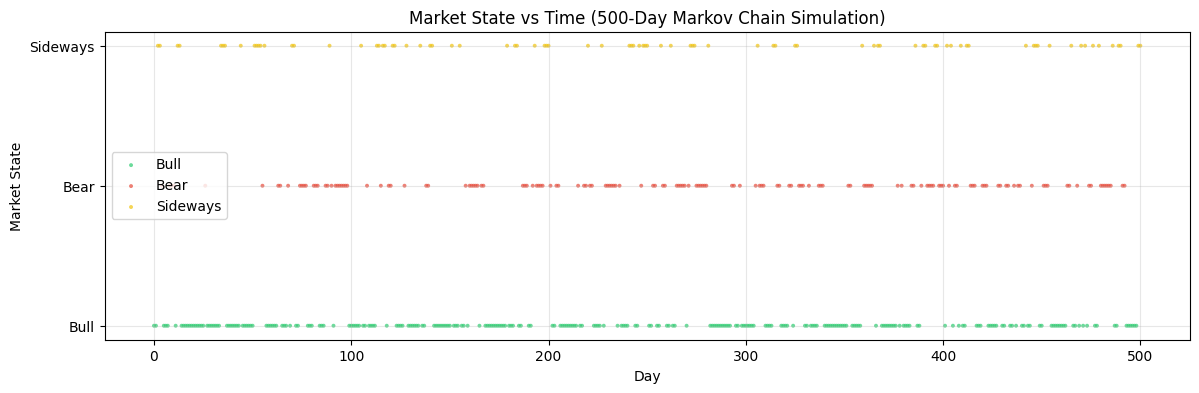

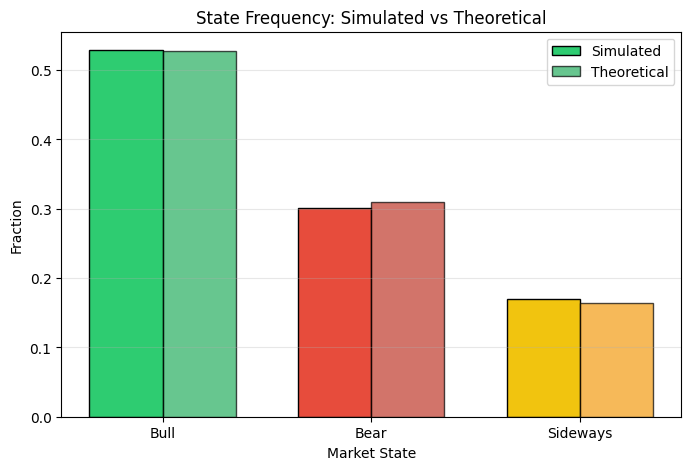

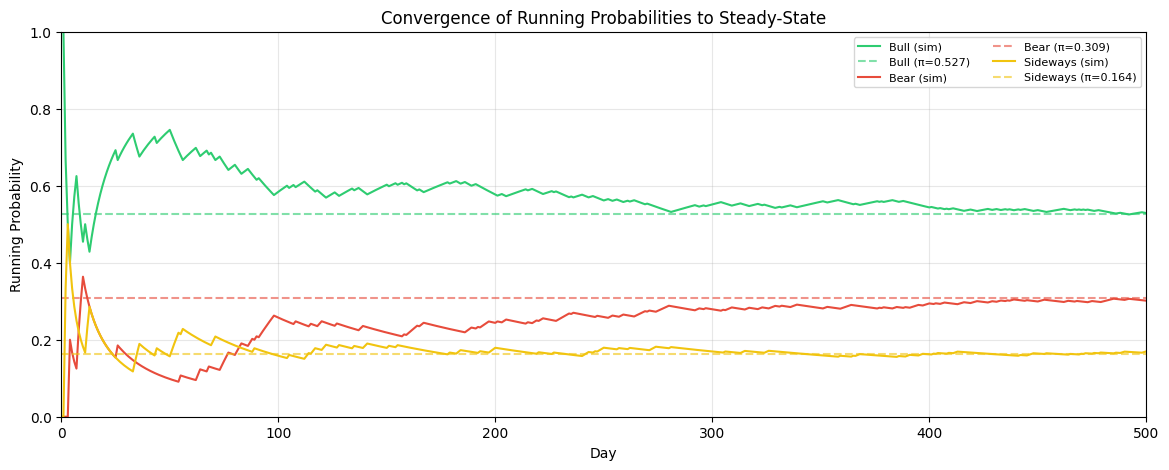

In [4]:
days = np.arange(len(states))

# Plot 1: Market State vs Time
fig, ax = plt.subplots(figsize=(14, 4))
for s in range(3):
    mask = np.array(states) == s
    ax.scatter(days[mask], np.array(states)[mask], c=STATE_COLORS[s],
               label=STATE_NAMES[s], s=8, alpha=0.7, edgecolors='none')
ax.set_xlabel("Day"); ax.set_ylabel("Market State")
ax.set_title("Market State vs Time (500-Day Markov Chain Simulation)")
ax.set_yticks([0,1,2]); ax.set_yticklabels(["Bull","Bear","Sideways"])
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

# Plot 2: Histogram of State Frequencies
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(3); w = 0.35
ax.bar(x - w/2, [emp_frac[s] for s in range(3)], w, label="Simulated",
       color=["#2ecc71","#e74c3c","#f1c40f"], edgecolor="black")
ax.bar(x + w/2, [pi[s] for s in range(3)], w, label="Theoretical",
       color=["#27ae60","#c0392b","#f39c12"], edgecolor="black", alpha=0.7)
ax.set_xlabel("Market State"); ax.set_ylabel("Fraction")
ax.set_title("State Frequency: Simulated vs Theoretical")
ax.set_xticks(x); ax.set_xticklabels(["Bull","Bear","Sideways"])
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.show()

# Plot 3: Running Probability Estimates Over Time
fig, ax = plt.subplots(figsize=(14, 5))
running_counts = np.zeros((len(states), 3))
for t, s in enumerate(states):
    if t > 0:
        running_counts[t] = running_counts[t-1]
    running_counts[t, s] += 1
running_frac = running_counts / np.arange(1, len(states)+1).reshape(-1,1)

for s in range(3):
    ax.plot(days, running_frac[:, s], color=STATE_COLORS[s],
            label=f"{STATE_NAMES[s]} (sim)", linewidth=1.5)
    ax.axhline(y=pi[s], color=STATE_COLORS[s], linestyle='--', alpha=0.6,
               label=f"{STATE_NAMES[s]} (π={pi[s]:.3f})")
ax.set_xlabel("Day"); ax.set_ylabel("Running Probability")
ax.set_title("Convergence of Running Probabilities to Steady-State")
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3); ax.set_xlim(0, NUM_DAYS); ax.set_ylim(0, 1)
plt.show()


## Task 2: Portfolio Simulation
Assign daily returns to each regime and track portfolio value.


Portfolio Simulation:
  Initial Capital: Rs 100,000.00
  Final Value:     Rs 243,241.63
  Total Return:    +143.24%


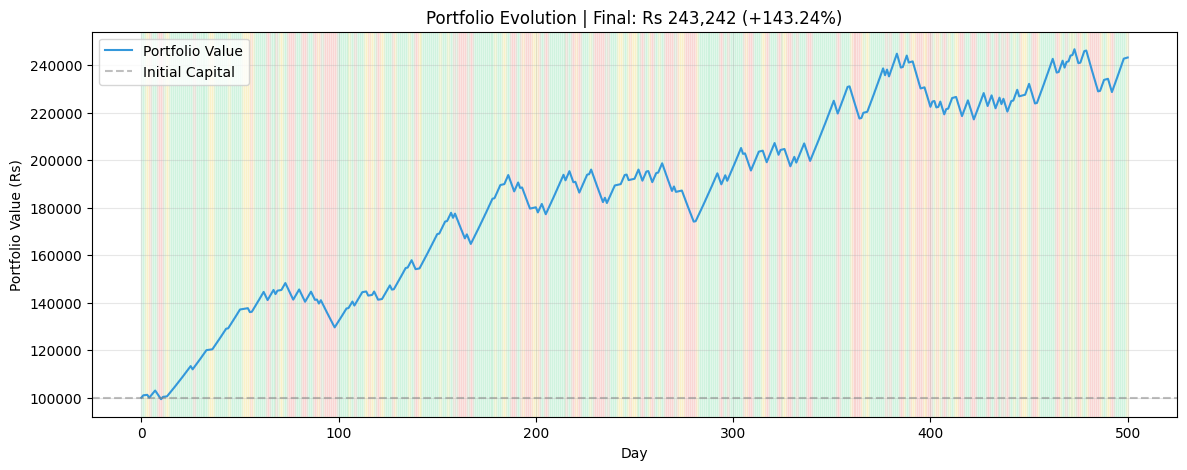

In [5]:
DAILY_RETURNS = {0: 0.01, 1: -0.012, 2: 0.001}
INITIAL_CAPITAL = 100_000
portfolio = [INITIAL_CAPITAL]
for t in range(1, len(states)):
    portfolio.append(portfolio[-1] * (1 + DAILY_RETURNS[states[t]]))
final_val = portfolio[-1]
total_ret = (final_val - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100
print(f"Portfolio Simulation:")
print(f"  Initial Capital: Rs {INITIAL_CAPITAL:,.2f}")
print(f"  Final Value:     Rs {final_val:,.2f}")
print(f"  Total Return:    {total_ret:+.2f}%")
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(days, portfolio, color="#3498db", linewidth=1.5, label="Portfolio Value")
ax.axhline(y=INITIAL_CAPITAL, color="gray", linestyle='--', alpha=0.5, label="Initial Capital")
for t in range(len(states)-1):
    ax.axvspan(t, t+1, alpha=0.08, color=STATE_COLORS[states[t]])
ax.set_xlabel("Day"); ax.set_ylabel("Portfolio Value (Rs)")
ax.set_title(f"Portfolio Evolution | Final: Rs {final_val:,.0f} ({total_ret:+.2f}%)")
ax.legend(loc="upper left"); ax.grid(True, alpha=0.3)
plt.show()


## Bonus Task: Google PageRank & Markov Chains

Google's PageRank algorithm models a "random surfer" who navigates the web by randomly clicking hyperlinks on each page they visit. Each webpage is treated as a **state** in a Markov Chain, and each hyperlink from page A to page B defines a transition probability. If page A has $n$ outgoing links, the probability of moving from A to any one of those linked pages is $1/n$. This satisfies the **Markov Property**: the next page the surfer visits depends *only* on the current page — not on any pages visited before.

The transition matrix of this web-graph Markov Chain captures the entire link structure of the web. However, not all pages have outgoing links ("dangling nodes"), and the graph may not be fully connected — so PageRank introduces a **"damping factor"** (typically $d = 0.85$). With probability $d$, the surfer follows a random link on the current page; with probability $(1 - d)$, they "teleport" to any page on the web uniformly at random. This ensures the Markov Chain is both **irreducible** (every page can be reached from every other page) and **aperiodic**, which guarantees that a unique steady-state distribution exists.

The **steady-state (stationary) distribution** $\pi$ of this modified Markov Chain gives the long-run fraction of time the random surfer spends on each page. Pages with higher steady-state probabilities are considered more "important" because they are visited more frequently — either because many other pages link to them or because highly-important pages link to them. This steady-state vector *is* the PageRank score, and it is computed by iteratively multiplying the state vector by the transition matrix until convergence, which is exactly how we find the stationary distribution of a Markov Chain.
